In [1]:
#import required Libaries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
#use CPU only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marquis03/bdd100k-scenario-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bdd100k-scenario-classification' dataset.
Path to dataset files: /kaggle/input/bdd100k-scenario-classification


In [4]:
print(os.listdir(path))

['val', 'test', 'train']


In [5]:
train_path = os.path.join(path, "train")
print(os.listdir(train_path))

['unknown', 'city street', 'highway', 'gas stations', 'parking lot', 'residential', 'tunnel']


In [6]:
import os
import hashlib
import pandas as pd

def get_file_hash(filepath, chunk_size=8192):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def collect_image_paths(root_dir):
    rows = []
    class_names = sorted(os.listdir(root_dir))

    for label_name in class_names:
        class_dir = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_dir):
            continue

        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            if os.path.isfile(fpath):
                rows.append({
                    "filepath": fpath,
                    "label": label_name,
                    "filename": fname
                })
    return pd.DataFrame(rows)

train_df = collect_image_paths(os.path.join(path, "train"))
train_df["md5"] = train_df["filepath"].apply(get_file_hash)

dup_exact = train_df[train_df.duplicated("md5", keep=False)].sort_values("md5")
print("Number of exact duplicate files:", dup_exact.shape[0])
print(dup_exact.head(20))


#The exact same dataset was found in 2 lables

Number of exact duplicate files: 2
                                                filepath        label  \
17514  /kaggle/input/bdd100k-scenario-classification/...  city street   
43775  /kaggle/input/bdd100k-scenario-classification/...      highway   

                    filename                               md5  
17514  6e09762a-bab508de.jpg  2610db2b184b4ff1e22349a81ceb2571  
43775  559b242e-90cd7279.jpg  2610db2b184b4ff1e22349a81ceb2571  


In [7]:
duplicate_md5s = train_df[train_df.duplicated("md5", keep=False)]["md5"].unique()
print("Duplicate hash values:", duplicate_md5s)

Duplicate hash values: ['2610db2b184b4ff1e22349a81ceb2571']


In [8]:
# loading and spliting the dataset for train/test/validation
from sklearn.model_selection import train_test_split

img_size = (224, 224)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

#cleaned duplicates
train_df = collect_image_paths(os.path.join(path, "train"))
train_df["md5"] = train_df["filepath"].apply(get_file_hash)

#remove all duplicates by hashing
train_df = train_df.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)

class_names = sorted(train_df["label"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}

train_df["label_idx"] = train_df["label"].map(class_to_index)


train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.3,
    stratify=train_df["label_idx"],
    random_state=42
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

test_df = collect_image_paths(os.path.join(path, "val"))
test_df["label_idx"] = test_df["label"].map(class_to_index)

# drop rows with labels not found in training classes, just in case
test_df = test_df.dropna(subset=["label_idx"]).reset_index(drop=True)
test_df["label_idx"] = test_df["label_idx"].astype(int)

def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["filepath"].values,
        df["label_idx"].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# Final datasets

with tf.device('/CPU:0'):
    train_dataset = make_dataset(train_split_df, shuffle=True)
    val_dataset = make_dataset(val_split_df, shuffle=False)
    test_dataset = make_dataset(test_df, shuffle=False)

print("Train samples:", len(train_split_df))
print("Validation samples:", len(val_split_df))
print("Test samples:", len(test_df))
print("Classes:", class_names)



Train samples: 48903
Validation samples: 20959
Test samples: 10000
Classes: ['city street', 'gas stations', 'highway', 'parking lot', 'residential', 'tunnel', 'unknown']


In [9]:
# Build Resnet Block
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, stride=1, l2= None):
        super().__init__()
        self.filters = filters
        self.stride = stride

        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding='same', kernel_regularizer=l2)
        self.bn1 = layers.BatchNormalization()

        self.conv2 = layers.Conv2D(filters, 3, strides=1, padding='same', kernel_regularizer=l2)
        self.bn2 = layers.BatchNormalization()


    def build(self, input_shape):
        if self.stride != 1 or input_shape[-1] != self.filters:
            self.shortcut = tf.keras.Sequential([
                layers.Conv2D(self.filters, 1, self.stride, padding='same'),
                layers.BatchNormalization()
            ])
        else:
            self.shortcut = lambda x: x   # identity

    def call(self, x):
        shortcut = self.shortcut(x)

        x = tf.nn.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x = x + shortcut
        return tf.nn.relu(x)

In [10]:
# Build Resnet Model
def build_resnet(input_shape=(224,224,3), num_classes=7):
    l2 = regularizers.l2(1e-4)

    inputs = layers.Input(shape=input_shape)

    # Initial layer
    x = layers.Conv2D(64, 7, strides=2, padding='same', kernel_regularizer=l2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual stages
    # Stage 1
    x = ResidualBlock(64, stride=1, l2=l2)(x)
    x = ResidualBlock(64, stride=1, l2=l2)(x)

    # Stage 2
    x = ResidualBlock(128, stride=2, l2=l2)(x)
    x = ResidualBlock(128, stride=1, l2=l2)(x)

    # Stage 3
    x = ResidualBlock(256, stride=2, l2=l2)(x)
    x = ResidualBlock(256, stride=1, l2=l2)(x)

    # Stage 4
    x = ResidualBlock(512, stride=2, l2=l2)(x)
    x = ResidualBlock(512, stride=1, l2=l2)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=l2
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model

In [11]:
# Configuring the model howto learn

model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ (None, 56, 56, 64)     │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 56, 56, 64)     │        74,368 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ (None, 28, 28, 128)    │       231,296 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_3                │ (None, 28, 28, 128)    │       296,192 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_4                │ (None, 14, 14, 256)    │       921,344 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_5                │ (None, 14, 14, 256)    │     1,182,208 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_6                │ (None, 7, 7, 512)      │     3,677,696 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_7                │ (None, 7, 7, 512)      │     4,723,712 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,257,479 (42.94 MB)

 Trainable params: 11,247,879 (42.91 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [12]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

Epoch 1/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 358s 231ms/step - accuracy: 0.6594 - loss: 1.2432 - val_accuracy: 0.6744 - val_loss: 1.1699
Epoch 2/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 353s 231ms/step - accuracy: 0.6999 - loss: 1.1008 - val_accuracy: 0.7067 - val_loss: 1.0593
Epoch 3/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - accuracy: 0.7139 - loss: 1.0108 - val_accuracy: 0.6363 - val_loss: 1.0706
Epoch 4/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - accuracy: 0.7239 - loss: 0.9322 - val_accuracy: 0.6372 - val_loss: 0.9960
Epoch 5/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - accuracy: 0.7369 - loss: 0.8668 - val_accuracy: 0.7151 - val_loss: 0.9037
Epoch 6/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - accuracy: 0.7488 - loss: 0.8102 - val_accuracy: 0.6893 - val_loss: 1.0339
Epoch 7/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - accuracy: 0.7658 - loss: 0.7553 - val_accuracy: 0.6963 - val_loss: 0.9625
Epoch 8/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 352s 230ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step


<Figure size 800x800 with 0 Axes>

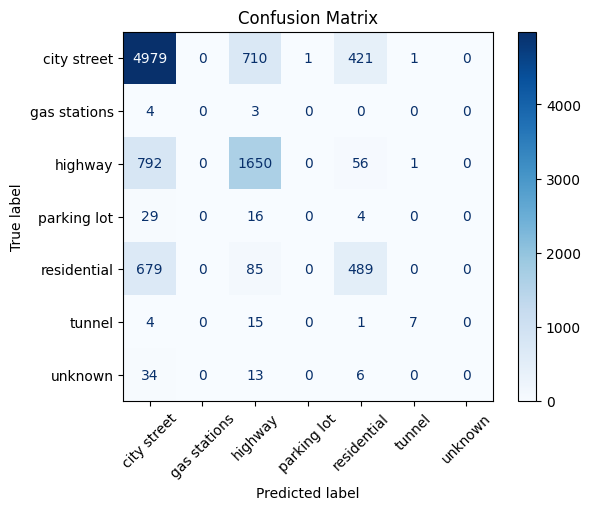

In [14]:
# Confusion Matrix
# Get true labels
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 city street       0.76      0.81      0.79      6112
gas stations       0.00      0.00      0.00         7
     highway       0.66      0.66      0.66      2499
 parking lot       0.00      0.00      0.00        49
 residential       0.50      0.39      0.44      1253
      tunnel       0.78      0.26      0.39        27
     unknown       0.00      0.00      0.00        53

    accuracy                           0.71     10000
   macro avg       0.39      0.30      0.33     10000
weighted avg       0.70      0.71      0.70     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


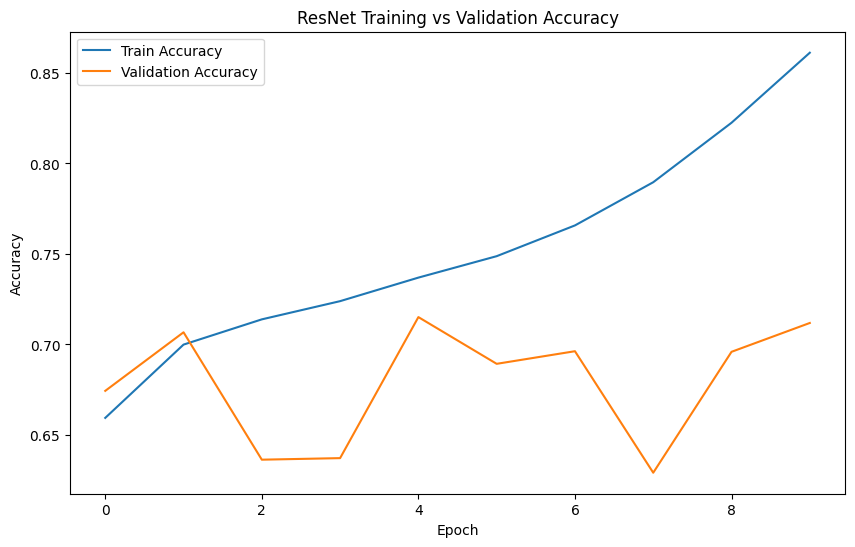

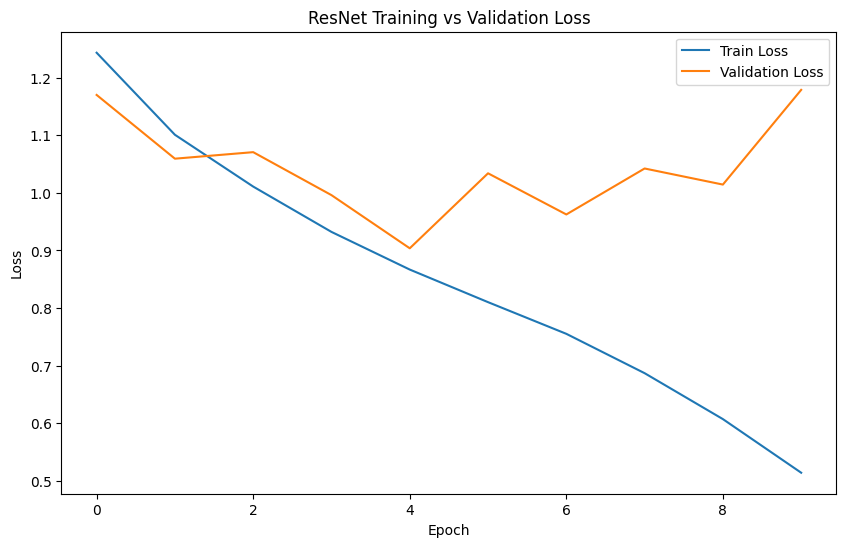

In [16]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Accuracy plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet Training vs Validation Loss')
plt.legend()
plt.show()